# StarDist vs Keras — per-timepoint nuclei comparison

Loads the CSV written by `compare-stardist-vs-keras.py` and plots one bar chart per metric (nuclei count, mean / total volume, mean radius, mean / total surface area) with side-by-side bars per timepoint — orange for StarDist, blue for Keras. Use this to eyeball whether your tuned StarDist over- or under-segments relative to the legacy keras pipeline.

The script writes `<input_stem>.compare.csv` into `compare_data_paths.out_dir`. Edit `CSV_PATH` below to point at it.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
CSV_PATH = Path("/mnt/jean-zay/demo_data/compare/timelapse_fifth_dataset.compare.csv")

# Optional voxel-spacing for physical-unit plots. Leave at 1.0 for
# voxel-space numbers (default — matches the script).
VOXEL_VOLUME_UM3 = 1.0   # multiply ``*_volume_vox`` by this to get µm³
VOXEL_LENGTH_UM = 1.0    # multiply ``mean_radius_vox`` by this to get µm
VOXEL_AREA_UM2 = 1.0     # multiply ``*_surface_area`` by this to get µm²

# Bar-chart colours.
COLOR_STARDIST = '#d4773a'
COLOR_KERAS = '#3a7ca5'

In [3]:
if not CSV_PATH.is_file():
    raise FileNotFoundError(
        f"{CSV_PATH} not found — run compare-stardist-vs-keras.py first"
    )
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df)} rows from {CSV_PATH}")
print(f"Sources: {df['source'].unique().tolist()}")
print(f"T-indices: {sorted(df['t_index'].unique().tolist())}")
df.head()

Loaded 30 rows from /mnt/jean-zay/demo_data/compare/timelapse_fifth_dataset.compare.csv
Sources: ['stardist', 'keras']
T-indices: [0, 1, 2, 3, 4, 93, 94, 95, 96, 97, 187, 188, 189, 190, 191]


,t_index,source,n_nuclei,mean_volume_vox,total_volume_vox,mean_radius_vox,mean_surface_area,total_surface_area
0,0,stardist,454,1235.123348,560746.0,6.322039,659.924384,299605.670486
1,0,keras,366,1285.986339,470671.0,6.639450,699.176312,255898.530060
2,1,stardist,469,1203.716418,564543.0,6.261071,648.464742,304129.963873
3,1,keras,377,1274.326260,480421.0,6.612595,693.607592,261490.062012
4,2,stardist,476,1211.779412,576807.0,6.287797,652.055250,310378.299199


In [4]:
# Pivot to wide form so each metric is a pair of columns (one per source).
metric_cols = [c for c in df.columns if c not in ('t_index', 'source')]
wide = df.pivot(index='t_index', columns='source', values=metric_cols).sort_index()
wide.columns = [f'{m}__{s}' for m, s in wide.columns]
wide.reset_index(inplace=True)
wide

,t_index,n_nuclei__keras,n_nuclei__stardist,mean_volume_vox__keras,mean_volume_vox__stardist,total_volume_vox__keras,total_volume_vox__stardist,mean_radius_vox__keras,mean_radius_vox__stardist,mean_surface_area__keras,mean_surface_area__stardist,total_surface_area__keras,total_surface_area__stardist
0,0,366.0,454.0,1285.986339,1235.123348,470671.0,560746.0,6.639450,6.322039,699.176312,659.924384,2.558985e+05,2.996057e+05
1,1,377.0,469.0,1274.326260,1203.716418,480421.0,564543.0,6.612595,6.261071,693.607592,648.464742,2.614901e+05,3.041300e+05
2,2,383.0,476.0,1298.412533,1211.779412,497292.0,576807.0,6.648163,6.287797,700.481618,652.055250,2.682845e+05,3.103783e+05
3,3,384.0,471.0,1318.661458,1190.673036,506366.0,560807.0,6.694118,6.296836,707.685703,647.926794,2.717513e+05,3.051735e+05
4,4,390.0,471.0,1313.015385,1213.322718,512076.0,571475.0,6.688552,6.320527,707.415453,654.806663,2.758920e+05,3.084139e+05
5,93,1325.0,1443.0,1246.796981,899.425502,1652006.0,1297871.0,6.565246,5.805111,703.077921,561.742625,9.315782e+05,8.105946e+05
6,94,1336.0,1462.0,1243.196108,887.854993,1660910.0,1298044.0,6.559042,5.779929,702.216128,557.884904,9.381607e+05,8.156277e+05
7,95,1360.0,1479.0,1231.869118,887.979716,1675342.0,1313322.0,6.534699,5.783924,697.278258,557.873218,9.482984e+05,8.250945e+05
8,96,1371.0,1527.0,1236.270605,870.163065,1694927.0,1328739.0,6.546025,5.721333,699.867567,548.872019,9.595184e+05,8.381276e+05
9,97,1394.0,1527.0,1235.309182,879.142109,1722021.0,1342450.0,6.540588,5.752165,699.725255,553.559147,9.754170e+05,8.452848e+05


In [5]:
# Per-metric mean across timepoints — a single-number sanity table.
rows = []
for m in metric_cols:
    sd = wide.get(f'{m}__stardist')
    kr = wide.get(f'{m}__keras')
    if sd is None or kr is None:
        continue
    rows.append({
        'metric': m,
        'stardist_mean': float(sd.mean()),
        'keras_mean': float(kr.mean()),
        'ratio_sd_over_keras': float(sd.mean() / kr.mean()) if kr.mean() else float('nan'),
    })
pd.DataFrame(rows)

,metric,stardist_mean,keras_mean,ratio_sd_over_keras
0,n_nuclei,1.704400e+03,1.476400e+03,1.154430
1,mean_volume_vox,9.379112e+02,1.210204e+03,0.775002
2,total_volume_vox,1.383190e+06,1.706339e+06,0.810618
3,mean_radius_vox,5.814061e+00,6.496257e+00,0.894986
4,mean_surface_area,5.711412e+02,6.929984e+02,0.824159
5,total_surface_area,9.087690e+05,1.013145e+06,0.896978


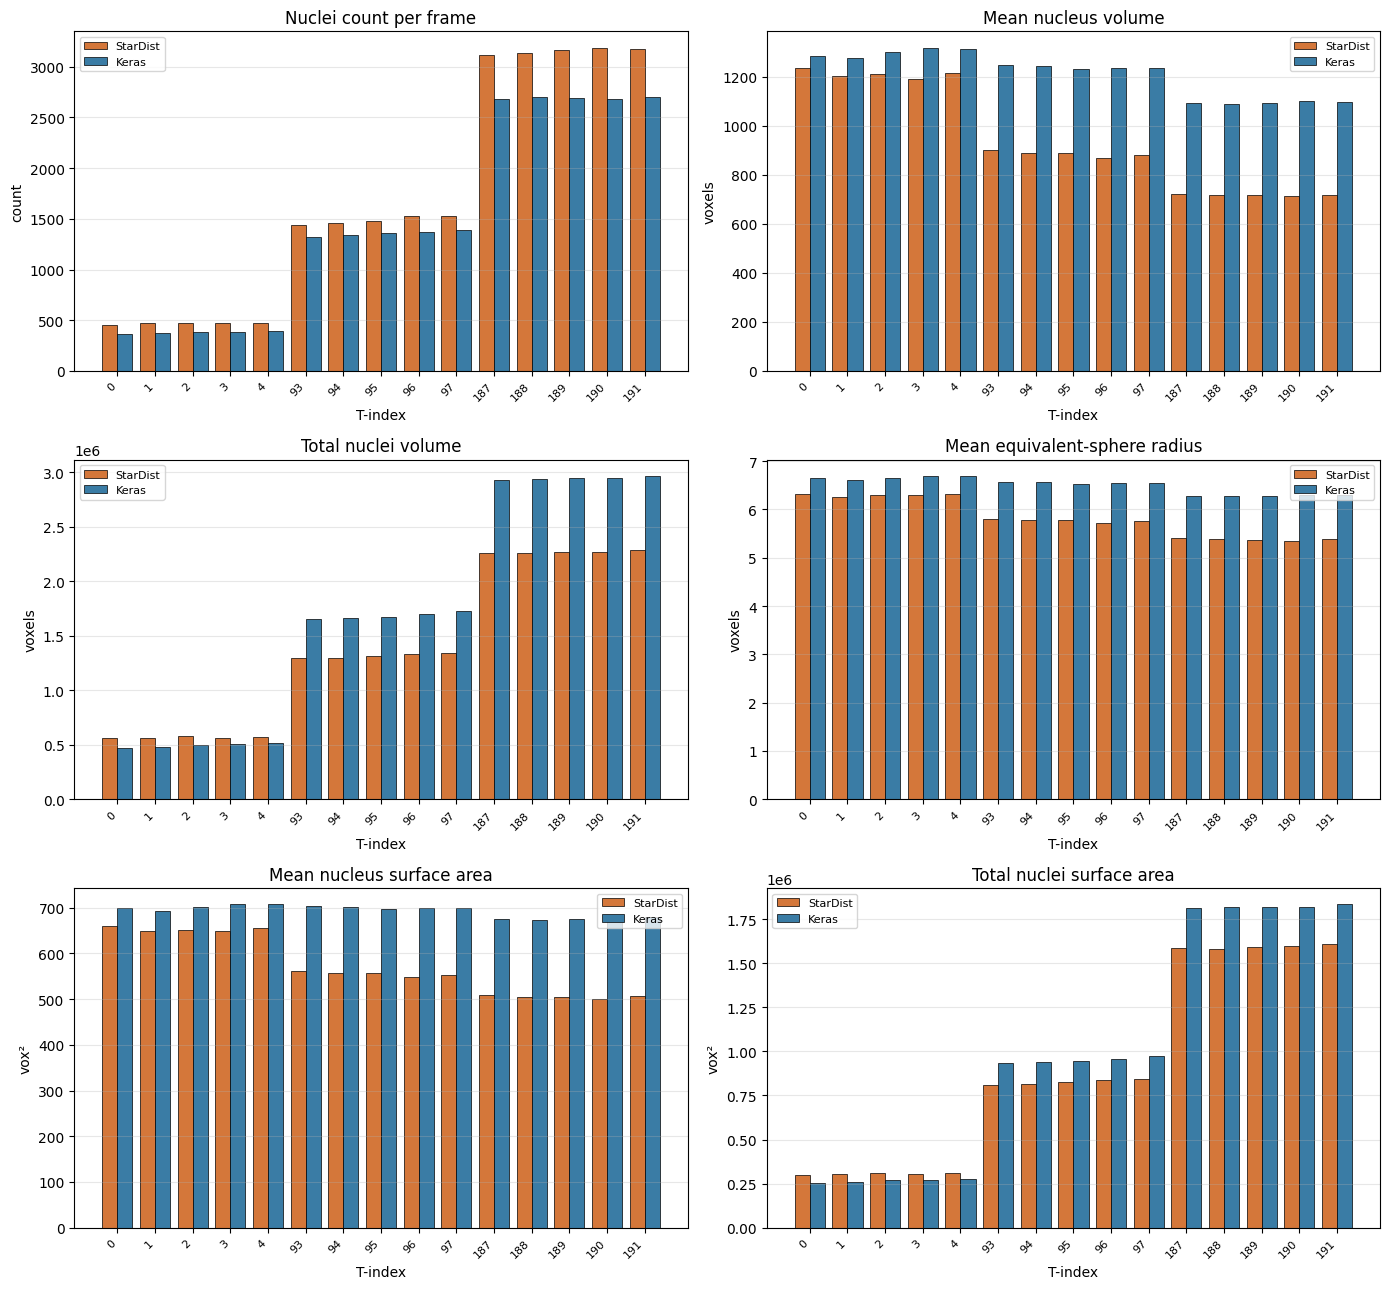

In [6]:
def _bar_pair(ax, ts, vals_sd, vals_kr, ylabel, title):
    """Side-by-side bars (StarDist orange, Keras blue) for one metric."""
    x = np.arange(len(ts))
    w = 0.4
    ax.bar(x - w/2, vals_sd, w, label='StarDist', color=COLOR_STARDIST, edgecolor='black', linewidth=0.5)
    ax.bar(x + w/2, vals_kr, w, label='Keras',    color=COLOR_KERAS,    edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in ts], rotation=45, ha='right', fontsize=8)
    ax.set_xlabel('T-index')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(fontsize=8, loc='best')


ts = wide['t_index'].tolist()

# Metrics → (ylabel, optional unit-scaling factor) for the bar charts.
plots = [
    ('n_nuclei',           'count',     1.0,                'Nuclei count per frame'),
    ('mean_volume_vox',    'voxels',    VOXEL_VOLUME_UM3,   'Mean nucleus volume'),
    ('total_volume_vox',   'voxels',    VOXEL_VOLUME_UM3,   'Total nuclei volume'),
    ('mean_radius_vox',    'voxels',    VOXEL_LENGTH_UM,    'Mean equivalent-sphere radius'),
    ('mean_surface_area',  'vox²',      VOXEL_AREA_UM2,     'Mean nucleus surface area'),
    ('total_surface_area', 'vox²',      VOXEL_AREA_UM2,     'Total nuclei surface area'),
]

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
axes = axes.flatten()
for ax, (metric, unit, scale, title) in zip(axes, plots):
    sd_col = f'{metric}__stardist'
    kr_col = f'{metric}__keras'
    if sd_col not in wide.columns or kr_col not in wide.columns:
        ax.set_axis_off()
        ax.set_title(f'{metric} — missing')
        continue
    _bar_pair(
        ax,
        ts,
        (wide[sd_col] * scale).to_numpy(),
        (wide[kr_col] * scale).to_numpy(),
        ylabel=unit,
        title=title,
    )
fig.tight_layout()
plt.show()